In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors as mcolors

import requests
from urllib.parse import urlencode
import io

# Load data

In [2]:
# Links to datasets
dataset_links = {
    'users_test': 'https://disk.yandex.ru/d/4XXIME4osGrMRA',
    'users_control_1': 'https://disk.yandex.ru/d/yJFydMNNGkEKfg',
    'users_control_2': 'https://disk.yandex.ru/d/br6KkQupzzTGoQ',
    'transactions_test': 'https://disk.yandex.ru/d/gvCWpZ55ODzs2g',
    'transactions_control_1': 'https://disk.yandex.ru/d/VY5W0keMX5TZBQ',
    'transactions_control_2': 'https://disk.yandex.ru/d/th5GL0mGOc-qzg',
}
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

# Store datasets in a dict for convenience
datasets = {}

# Load data
for name, link in dataset_links.items():
    print(f"Loading {name}...")
    
    # Get download link
    final_url = base_url + urlencode(dict(public_key=link))
    response = requests.get(final_url)
    download_url = response.json()['href']

    # Download and save df
    download_response = requests.get(download_url)
    datasets[name] = pd.read_csv(io.StringIO(download_response.text), sep=';')

Loading users_test...
Loading users_control_1...
Loading users_control_2...
Loading transactions_test...
Loading transactions_control_1...
Loading transactions_control_2...


In [3]:
# Custom data type
user_col_types = {
    'uid': 'Int64',
    'age': 'Int64',
    'attraction_coeff': 'Int64',
    'coins': 'Int64',
    'country': 'object',
    'visit_days': 'str',
    'gender': 'Int64',
    'age_filter_start': 'Int64',
    'age_filter_end': 'Int64',
    'views_count': 'Int64',
    'was_premium': 'Int64',
    'is_premium': 'Int64',
    'total_revenue': 'Int64'
    }

transactions_col_types = {
    'uid': 'Int64',
    'country': 'object',
    'joined_at':'datetime64[ns]',
    'paid_at':'datetime64[ns]',
    'revenue': 'Int64',
    'payment_id': 'Int64',
    'from_page': 'object',
    'product_type': 'object'
    }

# Loop over each data frame
for name in datasets.keys():
    if name.startswith('users_'):
        col_types = user_col_types
    else:
        col_types = transactions_col_types
    
    datasets[name] = datasets[name].astype(col_types)

# Preprocess

## IDs overlap

In [4]:
# Check for user ID overlap between groups
test_uids = set(datasets['users_test']['uid'])
c1_uids = set(datasets['users_control_1']['uid'])
c2_uids = set(datasets['users_control_2']['uid'])

print(f"test and control_1: {len(test_uids & c1_uids)}")
print(f"test and control_2: {len(test_uids & c2_uids)}")
print(f"control_1 and control_2: {len(c1_uids & c2_uids)}")

test and control_1: 0
test and control_2: 0
control_1 and control_2: 0


No one is simultaneously in two samples - all good

In [5]:
# Check uid overlap between users and transactions datasets
for name in ['test', 'control_1', 'control_2']:
    u_df = datasets[f'users_{name}']
    t_df = datasets[f'transactions_{name}']
    
    u_uids = set(u_df['uid'].unique())
    t_uids = set(t_df['uid'].unique())
    
    print(f"{name}:")
    print(f"  uid only in users: {len(u_uids - t_uids)}")
    print(f"  uid only in transactions: {len(t_uids - u_uids)}")
    print(f"  uid in both: {len(u_uids & t_uids)}\n")

test:
  uid only in users: 4162
  uid only in transactions: 0
  uid in both: 146

control_1:
  uid only in users: 4147
  uid only in transactions: 1
  uid in both: 193

control_2:
  uid only in users: 4077
  uid only in transactions: 0
  uid in both: 187



Some users made no transactions - this is expected

## Duplicates

In [6]:
# Check for duplicates 
for df_name, df in list(datasets.items()):
    print(df_name)
    print(f"Duplicate uids: {df["uid"].duplicated().sum()}")
    print(f"Full row duplicates: {df.duplicated().sum()}")
    print(f"Fully missing rows: {df.isna().all(axis=1).sum()}\n")

users_test
Duplicate uids: 0
Full row duplicates: 0
Fully missing rows: 0

users_control_1
Duplicate uids: 0
Full row duplicates: 0
Fully missing rows: 0

users_control_2
Duplicate uids: 0
Full row duplicates: 0
Fully missing rows: 0

transactions_test
Duplicate uids: 127
Full row duplicates: 7
Fully missing rows: 0

transactions_control_1
Duplicate uids: 813
Full row duplicates: 650
Fully missing rows: 630

transactions_control_2
Duplicate uids: 141
Full row duplicates: 5
Fully missing rows: 0



There are clear data quality issues: some tables contain full row duplicates and rows where every field is missing (most likely a data collection or export error). Note that duplicate `uid` values in `transactions_*` tables are expected - a single user may have made multiple purchases

In [7]:
# Drop fully missing rows
for df_name, df in datasets.items():
    if df.isna().all(axis=1).sum() > 0:
        datasets[df_name] = df[~df.isna().all(axis=1)]

# Drop full row duplicates
for df_name, df in datasets.items():
    if df.duplicated().sum() > 0:
        datasets[df_name] = df.drop_duplicates()

We also need to check for duplicated transactions - the same transaction may appear with different `payment_id` values while being identical in all other fields. These need to be removed

In [8]:
for df_name in ['transactions_test', 'transactions_control_1', 'transactions_control_2']:
    df = datasets[df_name]
    df_dup = df[df.duplicated(subset=['uid', 'paid_at', 'product_type'], keep=False)]
    
    print(f"\n{df_name}:")
    print(f"Number of duplicated rows: {len(df_dup)}:")
    print(df_dup[['uid', 'country', 'paid_at', 'product_type', 'revenue', 'payment_id']].sort_values(['uid', 'paid_at']).to_string())


transactions_test:
Number of duplicated rows: 8:
           uid                   country             paid_at      product_type  revenue  payment_id
152  891725043      United Arab Emirates 2017-10-29 07:48:00  premium_no_trial     9217         147
220  891725043      United Arab Emirates 2017-10-29 07:48:00  premium_no_trial     9217           0
71   892065108                    France 2017-10-11 15:27:00             coins      871          19
175  892065108                    France 2017-10-11 15:27:00             coins     3913          19
17   892236423  United States of America 2017-10-22 22:08:00             coins     1261          19
214  892236423  United States of America 2017-10-22 22:08:00             coins     6305          19
81   892236423  United States of America 2017-10-23 00:14:00             coins    31525          19
98   892236423  United States of America 2017-10-23 00:14:00             coins    12610          19

transactions_control_1:
Number of duplicated rows

Note that the records of interest (`product_type == premium_no_trial`) have `payment_id` values of 0 and 147. This likely indicates a payment processing failure. Other product types show similar issues, but these are not the focus of this analysis (see below)

In [9]:
# Drop duplicates by uid, paid_at, product_type
for df_name in ['transactions_test', 'transactions_control_1', 'transactions_control_2']:
    df = datasets[df_name]
    before = len(df)
    datasets[df_name] = df.drop_duplicates(subset=['uid', 'paid_at', 'product_type'], keep='last')

We have removed duplicates and empty rows. Next, we need to verify that the payment and registration dates are recorded correctly

## Date parsing errors

In [10]:
# Verify all payments were made after registration
for df_name, df in list(datasets.items())[3:]:  # Iterate over transaction datasets only
    print(df_name)
    print(((df.paid_at - df.joined_at).dt.days >= 0).value_counts())
    print()

transactions_test
True     216
False     46
Name: count, dtype: int64

transactions_control_1
True     288
False     54
Name: count, dtype: int64

transactions_control_2
True     253
False     60
Name: count, dtype: int64



In [11]:
# Date ranges for rows where payment preceded registration
for df_name, df in list(datasets.items())[3:]:
    bad = df[df['paid_at'] < df['joined_at']]
    print(f"\n{df_name}:")
    print(f"  joined_at range (bad): {bad['joined_at'].min().date()} - {bad['joined_at'].max().date()}")
    print(f"  paid_at range (bad):   {bad['paid_at'].min().date()} - {bad['paid_at'].max().date()}")
    print(f"  joined_at range (all): {df['joined_at'].min().date()} - {df['joined_at'].max().date()}")
    print(f"  paid_at range (all):   {df['paid_at'].min().date()} - {df['paid_at'].max().date()}")


transactions_test:
  joined_at range (bad): 2017-10-15 - 2017-10-31
  paid_at range (bad):   2017-01-11 - 2017-10-11
  joined_at range (all): 2017-01-11 - 2017-10-31
  paid_at range (all):   2017-01-11 - 2017-12-11

transactions_control_1:
  joined_at range (bad): 2017-10-14 - 2017-10-31
  paid_at range (bad):   2017-01-11 - 2017-10-11
  joined_at range (all): 2015-01-19 - 2017-10-31
  paid_at range (all):   2016-12-14 - 2017-12-11

transactions_control_2:
  joined_at range (bad): 2017-10-15 - 2017-10-31
  paid_at range (bad):   2017-01-11 - 2017-10-11
  joined_at range (all): 2017-01-11 - 2017-10-31
  paid_at range (all):   2017-01-11 - 2017-12-11


In [12]:
# Unique days and months of PAYMENT for rows where payment < registration
print('Unique days and months of PAYMENT where paid_at < joined_at:')
for df_name, df in list(datasets.items())[3:]:
    bad = df[df['paid_at'] < df['joined_at']]
    print(f"\n{df_name}:")
    print(f"  Days: {sorted(bad['paid_at'].dt.day.unique().tolist())}")
    print(f"  Months: {sorted(bad['paid_at'].dt.month.unique().tolist())}")

Unique days and months of PAYMENT where paid_at < joined_at:

transactions_test:
  Days: [11]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

transactions_control_1:
  Days: [11]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

transactions_control_2:
  Days: [11]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [13]:
# Unique days and months of PAYMENT for rows where payment >= registration
print('Unique days and months of PAYMENT where paid_at >= joined_at:')
for df_name, df in list(datasets.items())[3:]:
    bad = df[df['paid_at'] >= df['joined_at']]
    print(f"\n{df_name}:")
    print(f"  Days: {sorted(bad['paid_at'].dt.day.unique().tolist())}")
    print(f"  Months: {sorted(bad['paid_at'].dt.month.unique().tolist())}")

Unique days and months of PAYMENT where paid_at >= joined_at:

transactions_test:
  Days: [11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Months: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

transactions_control_1:
  Days: [11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

transactions_control_2:
  Days: [11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Months: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [14]:
# Unique days and months of REGISTRATION for rows where payment < registration
print('Unique days and months of REGISTRATION where paid_at < joined_at:')
for df_name, df in list(datasets.items())[3:]:
    bad = df[df['paid_at'] < df['joined_at']]
    print(f"\n{df_name}:")
    print(f"  Days: {sorted(bad['joined_at'].dt.day.unique().tolist())}")
    print(f"  Months: {sorted(bad['joined_at'].dt.month.unique().tolist())}")

Unique days and months of REGISTRATION where paid_at < joined_at:

transactions_test:
  Days: [15, 17, 18, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31]
  Months: [10]

transactions_control_1:
  Days: [14, 15, 16, 17, 18, 20, 21, 23, 25, 26, 28, 29, 30, 31]
  Months: [10]

transactions_control_2:
  Days: [15, 16, 17, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Months: [10]


In [15]:
# Unique days and months of REGISTRATION for rows where payment >= registration
print('Unique days and months of REGISTRATION where paid_at >= joined_at:')
for df_name, df in list(datasets.items())[3:]:
    bad = df[df['paid_at'] >= df['joined_at']]
    print(f"\n{df_name}:")
    print(f"  Days: {sorted(bad['joined_at'].dt.day.unique().tolist())}")
    print(f"  Months: {sorted(bad['joined_at'].dt.month.unique().tolist())}")

Unique days and months of REGISTRATION where paid_at >= joined_at:

transactions_test:
  Days: [11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 10]

transactions_control_1:
  Days: [11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

transactions_control_2:
  Days: [11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
  Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In all erroneous rows, the payment day is always 11, but the month varies from January to October. This pattern is absent in the registration dates. The error occurred during data export for `paid_at`: most records follow `YYYY-MM-DD` format, while a subset used `YYYY-DD-MM`, causing day and month to be swapped

In [16]:
# Fix date parsing errors in paid_at
# and verify no issues remain
for df_name, df in list(datasets.items())[3:]:
    mask = df['paid_at'] < df['joined_at']
    
    fixed = pd.to_datetime({
        'year': df.loc[mask, 'paid_at'].dt.year,
        'month': df.loc[mask, 'paid_at'].dt.day, # 11 → November (month)
        'day': df.loc[mask, 'paid_at'].dt.month, # actual day
        'hour': df.loc[mask, 'paid_at'].dt.hour,
        'minute': df.loc[mask, 'paid_at'].dt.minute,
        'second': df.loc[mask, 'paid_at'].dt.second
    }, errors='coerce')
    
    datasets[df_name].loc[mask, 'paid_at'] = fixed
    
    # Verify
    still_bad = datasets[df_name]['paid_at'] < datasets[df_name]['joined_at']
    print(f"{df_name}: fixed {mask.sum()}, remaining issues: {still_bad.sum()}")

transactions_test: fixed 46, remaining issues: 0
transactions_control_1: fixed 54, remaining issues: 0
transactions_control_2: fixed 60, remaining issues: 0


Additional sanity check: a trial subscription must precede a full subscription. Any other order is logically inconsistent

In [17]:
# Sanity check: trial subscription must precede full subscription
for df_name in ['transactions_test', 'transactions_control_1', 'transactions_control_2']:
    df = datasets[df_name]
    
    bad_uids = []
    
    for uid, group in df.groupby('uid'):
        group = group.sort_values('paid_at')
        
        has_trial = 'trial_premium' in group['product_type'].values
        has_premium = 'premium_no_trial' in group['product_type'].values
        
        if not (has_trial and has_premium):
            continue
        
        trial_date = group[group['product_type'] == 'trial_premium']['paid_at'].min()
        premium_date = group[group['product_type'] == 'premium_no_trial']['paid_at'].min()
        
        if premium_date < trial_date:
            bad_uids.append(uid)
    
    print(f"{df_name}: violations (premium_no_trial before trial): {len(bad_uids)}")
    for uid in bad_uids:
        print(f"\n  uid {uid}:")
        print(df[df['uid'] == uid][['joined_at','paid_at', 'product_type', 'revenue']].sort_values('paid_at').to_string())
        print()

transactions_test: violations (premium_no_trial before trial): 1

  uid 892065108:
              joined_at             paid_at      product_type  revenue
38  2017-10-21 20:40:00 2017-11-08 22:45:00  premium_no_trial     7098
185 2017-10-21 20:40:00 2017-11-09 10:45:00  premium_no_trial     7098
213 2017-10-21 20:40:00 2017-11-10 15:24:00  premium_no_trial     7111
114 2017-10-21 20:40:00 2017-11-10 15:26:00             coins      871
175 2017-10-21 20:40:00 2017-11-10 15:27:00             coins     3913
141 2017-10-21 20:40:00 2017-11-11 03:28:00     trial_premium    12454
52  2017-10-21 20:40:00 2017-12-11 02:10:00             coins     3913
180 2017-10-21 20:40:00 2017-12-11 02:11:00             coins     3913

transactions_control_1: violations (premium_no_trial before trial): 0
transactions_control_2: violations (premium_no_trial before trial): 0


Only one user had this anomaly. He attempted to purchase a full subscription on three consecutive days but ended up buying only a trial. The most likely explanation is a payment processing failure for the full subscription (and possibly for the coin purchases on November 10, 2017), which ultimately forced him to fall back to the trial. A more detailed event log would be needed to confirm this.

Let's now review the overall date ranges after cleaning

In [18]:
# Date ranges for registration and payment
for df_name, df in list(datasets.items())[3:]:
    print(f"\n{df_name}:")
    print(f"  joined_at range: {df["joined_at"].min().date()} – {df['joined_at'].max().date()}")
    print(f"  paid_at range:   {df["paid_at"].min().date()} – {df['paid_at'].max().date()}")


transactions_test:
  joined_at range: 2017-01-11 – 2017-10-31
  paid_at range:   2017-02-11 – 2017-12-11

transactions_control_1:
  joined_at range: 2015-01-19 – 2017-10-31
  paid_at range:   2016-12-14 – 2017-12-11

transactions_control_2:
  joined_at range: 2017-01-11 – 2017-10-31
  paid_at range:   2017-02-11 – 2017-12-11


Records from 2015 and 2016 are present in `transactions_control_1`, which is suspicious given the experiment was clearly conducted in 2017.

## Activity dates

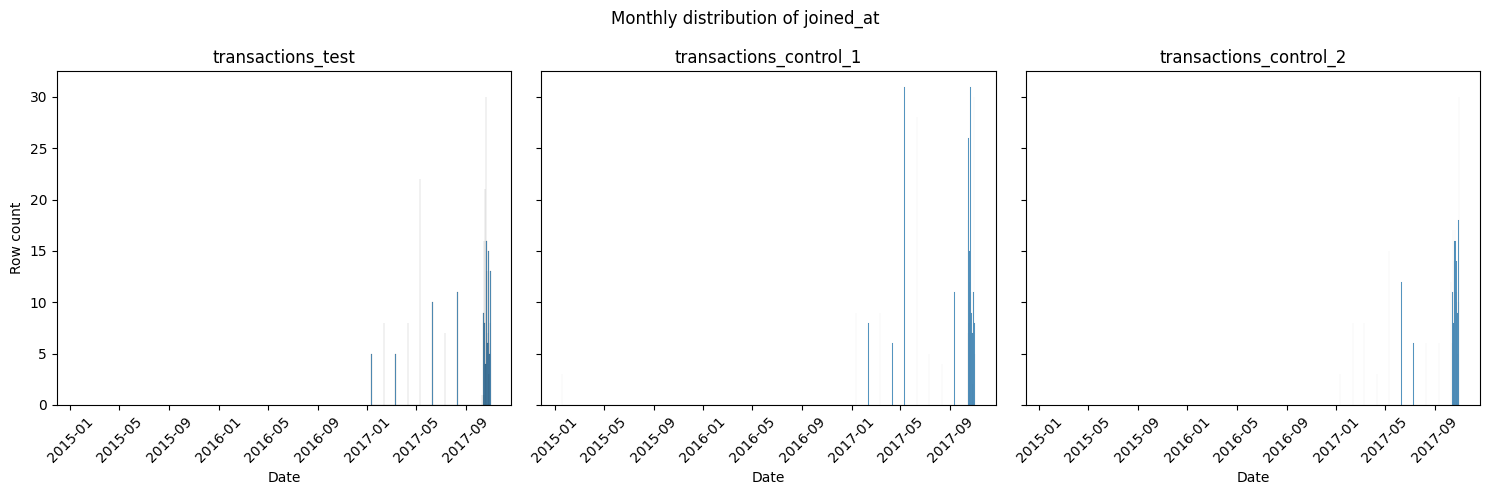

In [19]:
# Check distribution of registration dates
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         sharex = True, sharey = True)
for i, (df_name, df) in enumerate(list(datasets.items())[3:]):
    sns.histplot(df['joined_at'].dt.date, kde=False, ax=axes[i])
    axes[i].set_title(f"{df_name}")
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Row count')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly distribution of joined_at')
plt.ylabel('Row count')
plt.tight_layout()
plt.show()

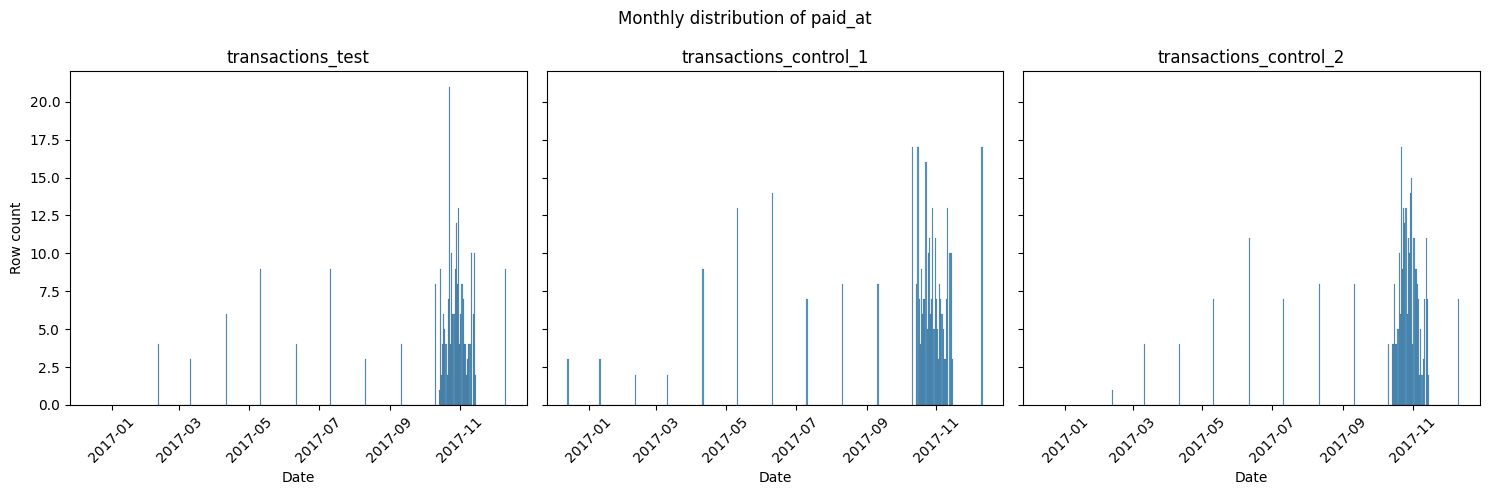

In [20]:
# Check distribution of payment dates
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         sharex = True, sharey = True)
for i, (df_name, df) in enumerate(list(datasets.items())[3:]):
    sns.histplot(df['paid_at'].dt.date, kde=False, ax=axes[i])
    axes[i].set_title(f"{df_name}")
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Row count')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly distribution of paid_at')
plt.ylabel('Row count')
plt.tight_layout()
plt.show()

The distributions show that the majority of transactions occurred in October-November 2017. Let's check full subscriptions only.

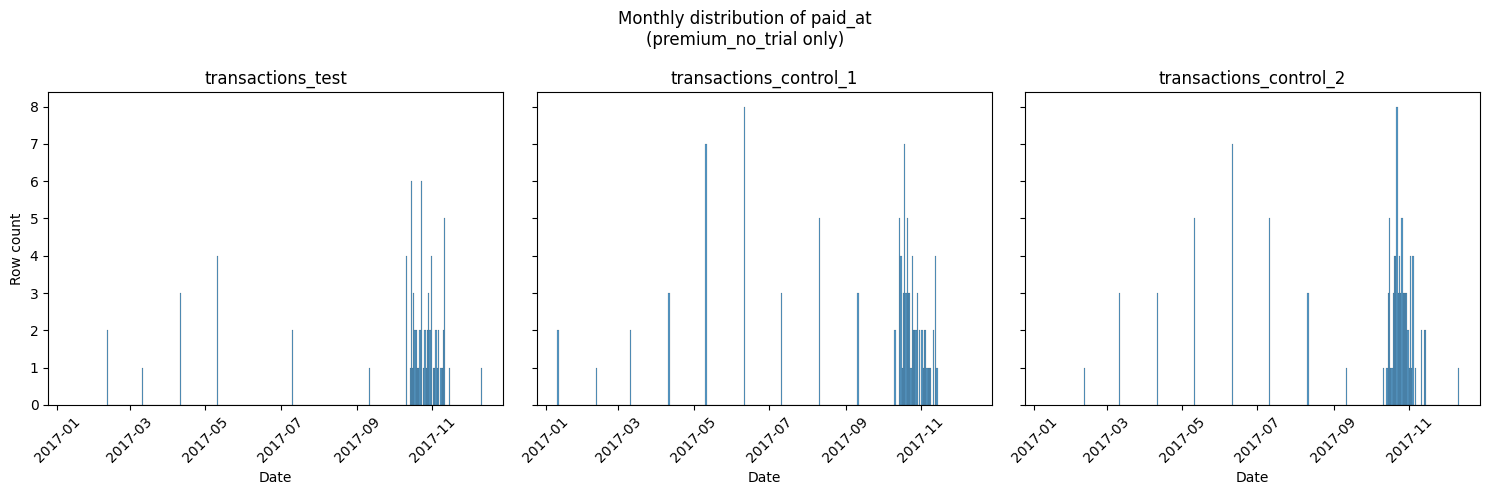

In [21]:
# Check distribution of full subscription payment dates
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         sharex = True, sharey = True)
for i, (df_name, df) in enumerate(list(datasets.items())[3:]):
    df_premium = df.query('product_type == "premium_no_trial"')
    sns.histplot(df_premium['paid_at'].dt.date, kde=False, ax=axes[i])
    axes[i].set_title(f"{df_name}")
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Row count')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly distribution of paid_at\n(premium_no_trial only)')
plt.ylabel('Row count')
plt.tight_layout()
plt.show()

After cleaning, only 2017 data remains. A year-long A/B test is unusually long and may suggest additional data pipeline issues. Without further context we assume the experiment ran for the full year, with a marketing campaign (or similar event) in Oct-Nov 2017 driving a spike in new users. Crucially, this pattern is consistent across all three groups.

## Transaction frequency

One more duplicate check is needed. We know subscriptions are billed monthly, yet some users appear to have paid for a full subscription multiple times within days or even minutes. For example, `uid=892065108` attempted to pay for the full subscription on three consecutive days before ending up with a trial.

In [22]:
# Identify succesfull transactions:
# 1. Last premium_no_trial transaction in a every month
# 2. None of premium_no_trial transaction if a trial_premium was bought after premium_no_trial
for df_name in ['transactions_test', 'transactions_control_1', 'transactions_control_2']:
    df = datasets[df_name].copy()
    
    df['successful_transaction'] = pd.NA
    
    # Work only with premium_no_trial
    premium_mask = df['product_type'] == 'premium_no_trial'
    premium_df = df[premium_mask].copy()
    premium_df['year_month'] = premium_df['paid_at'].dt.to_period('M')
    
    # For each uid+month, mark the last transaction as True, others as False
    last_idx = premium_df.groupby(['uid', 'year_month'])['paid_at'].idxmax()
    
    df.loc[premium_mask, 'successful_transaction'] = False
    df.loc[last_idx, 'successful_transaction'] = True
    
    # Users who have trial_premium AFTER premium_no_trial -
    # mark all their premium_no_trial transactions as unsuccessful
    for uid, group in df[df['product_type'].isin(['premium_no_trial', 'trial_premium'])].groupby('uid'):
        if 'trial_premium' not in group['product_type'].values:
            continue
        trial_date = group[group['product_type'] == 'trial_premium']['paid_at'].min()
        premium_before_trial = group[
            (group['product_type'] == 'premium_no_trial') &
            (group['paid_at'] < trial_date)
        ].index
        if len(premium_before_trial) > 0:
            df.loc[premium_before_trial, 'successful_transaction'] = False
    
    datasets[df_name] = df

## Users and transactions dataset overlap

In [23]:
# Check uid overlap between users and transactions datasets
for name in ['test', 'control_1', 'control_2']:
    u_df = datasets[f'users_{name}']
    t_df = datasets[f'transactions_{name}']
    
    u_uids = set(u_df['uid'].unique())
    t_uids = set(t_df['uid'].unique())
    
    print(f"{name}:")
    print(f"  uid only in users: {len(u_uids - t_uids)}")
    print(f"  uid only in transactions: {len(t_uids - u_uids)}")
    print(f"  uid in both: {len(u_uids & t_uids)}\n")

test:
  uid only in users: 4162
  uid only in transactions: 0
  uid in both: 146

control_1:
  uid only in users: 4147
  uid only in transactions: 0
  uid in both: 193

control_2:
  uid only in users: 4077
  uid only in transactions: 0
  uid in both: 187



Some users made no transactions - this is expected

# EDA

Checking group balance across:

- Gender ratio

- Countries

- Age

- Attraction coefficient

### Gender

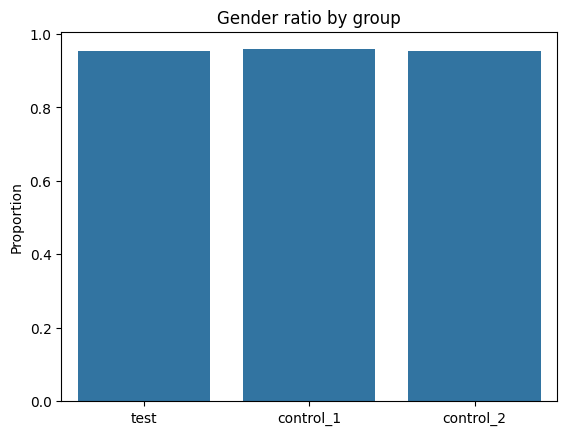

In [24]:
# Gender distribution
mean_gender = []
for name in ['test', 'control_1', 'control_2']:
    df = datasets[f'users_{name}']
    mean_gender.append(df.gender.mean())

# Plot
ax = sns.barplot(x = ['test', 'control_1', 'control_2'], y = mean_gender)
ax.set_ylabel('Proportion')
ax.set_title('Gender ratio by group')
plt.show()

The gender ratio within each group is heavily skewed, but the proportions are equal across groups, which is what matters for a valid A/B test

### Country

In [25]:
# Country proportions per group
countries = pd.DataFrame()
for name in ['test', 'control_1', 'control_2']:
    df = datasets[f'users_{name}']
    country_prop = df.country.value_counts(normalize=True).reset_index('country')
    country_prop.columns = ['country', name]
    if len(countries) == 0:
        countries = country_prop
    else:
        countries = countries.merge(country_prop, on = 'country', how='left')

# Keep only countries with > 0.5% share in at least one group - smaller shares are negligible
countries = countries[(countries['test'] > 0.005) | (countries['control_1'] > 0.005) | (countries['control_1'] > 0.005)]
# Convert to long format
countries_long = countries.melt(id_vars='country',value_name='prop',var_name='sample')

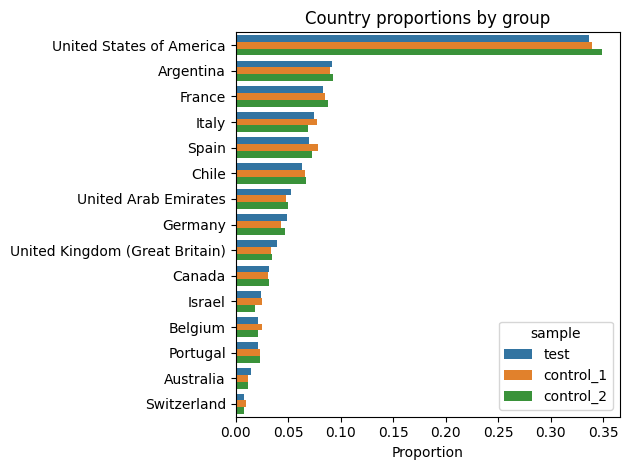

In [26]:
# Plot
ax = sns.barplot(data=countries_long, y='country',x='prop', hue='sample')
ax.set_xlabel('Proportion')
ax.set_ylabel(None)
ax.set_title('Country proportions by group')
plt.tight_layout()
plt.show()

Country proportions are roughly equal across groups

### Age

In [27]:
# Merge test, control 1 and control 2 users datasets
age_test = datasets['users_test'].loc[:,['uid','age']]
age_test['sample'] = 'test'

age_control_1 = datasets['users_control_1'].loc[:,['uid','age']]
age_control_1['sample'] = 'control_1'

age_control_2 = datasets['users_control_2'].loc[:,['uid','age']]
age_control_2['sample'] = 'control_2'

ages = pd.concat([age_test,age_control_1,age_control_2], ignore_index=True)

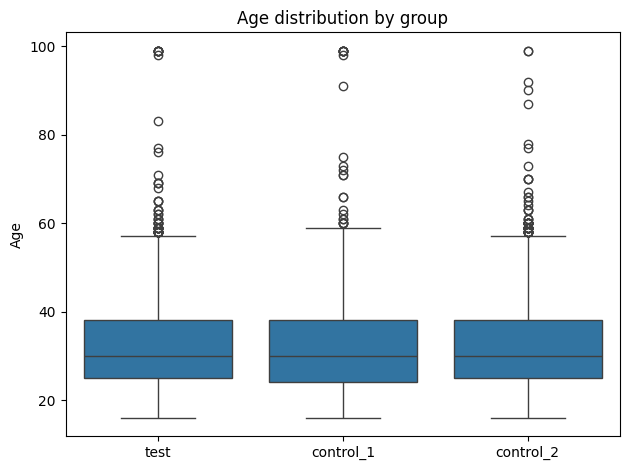

In [28]:
# Plot
ax = sns.boxplot(data=ages, x='sample', y='age')
ax.set_xlabel(None)
ax.set_ylabel('Age')
ax.set_title('Age distribution by group')
plt.tight_layout()
plt.show()

Age distributions are comparable across groups

### Attractiveness

In the context of a dating app, it is important that groups are balanced by attraction coefficient, as this could confound behavioural differences between groups.

In [29]:
# Merge test, control 1 and control 2 users datasets
attract_test = datasets['users_test'].loc[:,['uid','attraction_coeff']]
attract_test['sample'] = 'test'

attract_control_1 = datasets['users_control_1'].loc[:,['uid','attraction_coeff']]
attract_control_1['sample'] = 'control_1'

attract_control_2 = datasets['users_control_2'].loc[:,['uid','attraction_coeff']]
attract_control_2['sample'] = 'control_2'

attract = pd.concat([attract_test,attract_control_1,attract_control_2], ignore_index=True)

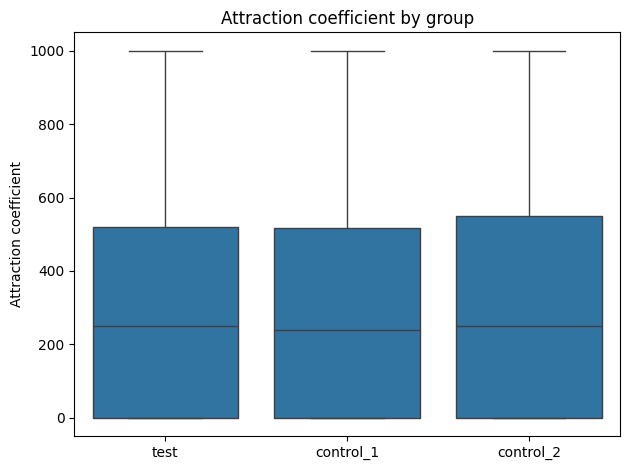

In [30]:
# Plot
ax = sns.boxplot(data=attract, x='sample', y='attraction_coeff')
ax.set_xlabel(None)
ax.set_ylabel('Attraction coefficient')
ax.set_title('Attraction coefficient by group')
plt.tight_layout()
plt.show()

Values are comparable across groups

# Analysis

Metrics:

- Conversion (primary metric)

    - From trial to full subscription. If the new pricing for the new payment methods positively influenced user behaviour, conversion should increase in the test group relative to controls. This analysis uses all users who ever purchased a trial subscription.

    - From new user to `premium_no_trial` purchase. Of all new users, how many go directly to the full subscription rather than opting for a trial or a coins-based subscription?

- ARPPU (proxy metric). Did users in the test group spend more on other purchases as a result of the (presumably lower) subscription price via new payment methods? For example: 'Alice pays by card and can only afford the subscription, while Bob pays via a new method at a lower price and has money left to spend on other purchases.' This analysis uses only users who purchased the full subscription, also including their `other_type` purchases

- Daily retention (guardrail metric). A change in payment method pricing should not directly affect how often users open the app after registration. If the new payment methods haven't broken anything, there should be no difference across groups

- Payment failures (guardrail metric). We have already observed that full subscription payments sometimes fail, forcing users to retry after minutes, hours, or days. We do not want the new payment methods to increase the share of failed transactions relative to the control groups


## Trial → full subscription conversion

In [31]:
# How many users purchased both subscriptions
for name in ['test', 'control_1', 'control_2']:
    t_df = datasets[f'transactions_{name}']
    
    trial_uids = set(t_df[t_df['product_type'] == 'trial_premium']['uid'].unique())
    premium_uids = set(t_df[t_df['product_type'] == 'premium_no_trial']['uid'].unique())
    converted = trial_uids & premium_uids
    
    print(f"{name}:")
    print(f"  Purchased trial: {len(trial_uids)}")
    print(f"  Purchased premium_no_trial: {len(premium_uids)}")
    print(f"  Purchased both (conversion): {len(converted)}\n")

test:
  Purchased trial: 61
  Purchased premium_no_trial: 67
  Purchased both (conversion): 1

control_1:
  Purchased trial: 67
  Purchased premium_no_trial: 99
  Purchased both (conversion): 0

control_2:
  Purchased trial: 53
  Purchased premium_no_trial: 102
  Purchased both (conversion): 0



Only one user across all groups purchased both subscription types - and we already flagged his payments as failed transactions, since he attempted to pay for a full subscription on three consecutive days and ultimately fell back to the trial, not the other way around.

No user followed the trial → full subscription path. This is either a data artefact or a product bug, since trial-to-paid conversion is typically a core user journey.

## New users → premium conversion

In [32]:
# Merge users and transactions datasets
for name in ['test', 'control_1', 'control_2']:
    u_df = datasets[f'users_{name}']
    t_df = datasets[f'transactions_{name}']
    
    datasets[f'merged_{name}'] = u_df.merge(t_df, on=['uid', 'country'], how='left')

In [33]:
# Compute conversion
conv_into_premium = {}
conv_into_premium['sample'] = []
conv_into_premium['total_users'] = []
conv_into_premium['premium_no_trial_users'] = []
conv_into_premium['conversion'] = []

for name in ['test', 'control_1', 'control_2']:
    df = datasets[f'merged_{name}']
    all_ids = df['uid'].unique()
    
    clean_premium_uids = []
    
    for uid, group in df[df['product_type'].isin(['coins', 'trial_premium', 'premium_no_trial'])].groupby('uid'):
        group = group.sort_values('paid_at')
        
        if 'premium_no_trial' not in group['product_type'].values:
            continue
        
        # Only successful premium_no_trial transactions
        successful_premium = group[
            (group['product_type'] == 'premium_no_trial') &
            (group['successful_transaction'] == True)
        ]
        
        if len(successful_premium) == 0:
            continue
        
        first_premium_date = successful_premium['paid_at'].min()
        before_premium = group[group['paid_at'] < first_premium_date]
        
        if not before_premium['product_type'].isin(['coins', 'trial_premium']).any():
            clean_premium_uids.append(uid)
    
    conv_into_premium['sample'].append(name)
    conv_into_premium['total_users'].append(len(all_ids))
    conv_into_premium['premium_no_trial_users'].append(len(clean_premium_uids))
    conv_into_premium['conversion'].append(len(clean_premium_uids)/len(all_ids))

conv_into_premium = pd.DataFrame(conv_into_premium)
conv_into_premium['conversion_percent'] = conv_into_premium['conversion'] * 100
conv_into_premium

,sample,total_users,premium_no_trial_users,conversion,conversion_percent
0,test,4308,57,0.013231,1.323120
1,control_1,4340,90,0.020737,2.073733
2,control_2,4264,93,0.021811,2.181051


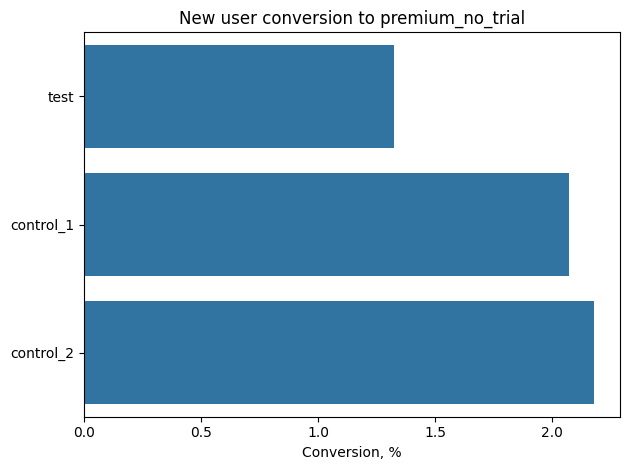

In [34]:
# Plot
ax = sns.barplot(data=conv_into_premium, y='sample', x='conversion_percent')
ax.set_ylabel(None)
ax.set_xlabel('Conversion, %')
ax.set_title('New user conversion to premium_no_trial')
plt.tight_layout()
plt.show()

In [35]:
# Statistical test: Chi-square
contingency_table = np.array([list(conv_into_premium['premium_no_trial_users']), 
                              list(conv_into_premium['total_users'] - conv_into_premium['premium_no_trial_users'])])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square: {chi2:.3f}, p-value: {p:.4f}, df: {dof}")

Chi-square: 10.303, p-value: 0.0058, df: 2


Significant differences detected - proceeding with pairwise comparisons

In [36]:
# Pairwise z-tests with Bonferroni correction
pairs = [('test', 'control_1'), ('test', 'control_2'), ('control_1', 'control_2')]
n_pairs = len(pairs)

for g1, g2 in pairs:
    # Premium count and total
    k1 = conv_into_premium.loc[conv_into_premium['sample'] == g1, 'premium_no_trial_users'].values[0]
    n1 = conv_into_premium.loc[conv_into_premium['sample'] == g1, 'total_users'].values[0]
    
    k2 = conv_into_premium.loc[conv_into_premium['sample'] == g2, 'premium_no_trial_users'].values[0]
    n2 = conv_into_premium.loc[conv_into_premium['sample'] == g2, 'total_users'].values[0]
    
    stat, p = proportions_ztest([k1, k2], [n1, n2])
    p_cor = min(n_pairs*p, 1.00)
    conv1 = k1/n1
    conv2 = k2/n2
    
    print(f"{g1} vs {g2}: {conv1:.2%} vs {conv2:.2%}, adj p-value={p_cor:.4f} {'***' if p_cor < 0.05 else ''}")

test vs control_1: 1.32% vs 2.07%, adj p-value=0.0208 ***
test vs control_2: 1.32% vs 2.18%, adj p-value=0.0074 ***
control_1 vs control_2: 2.07% vs 2.18%, adj p-value=1.0000 


Chi-square test and pairwise comparisons show a statistically significant decrease in conversion from new user to `premium_no_trial` in the test group relative to both control groups

## ARPPU

In [37]:
# Compute ARPPU
arppu_data = {}

for name in ['test', 'control_1', 'control_2']:
    t_df = datasets[f'transactions_{name}']
    
    # Users who successfully purchased premium_no_trial
    premium_uids = set(t_df[
        (t_df['product_type'] == 'premium_no_trial') &
        (t_df['successful_transaction'] == True)
    ]['uid'].unique())
    
    # Their transactions
    relevant = t_df[
        t_df['uid'].isin(premium_uids) &
        t_df['product_type'].isin(['premium_no_trial', 'other_type']) &
        # exclude unsuccessful premium_no_trial purchases
        ((t_df['product_type'] != 'premium_no_trial') | (t_df['successful_transaction'] == True))
    ]
    
    # Total revenue per user
    revenue_per_user = relevant.groupby('uid')['revenue'].sum()
    
    arppu_data[name] = revenue_per_user

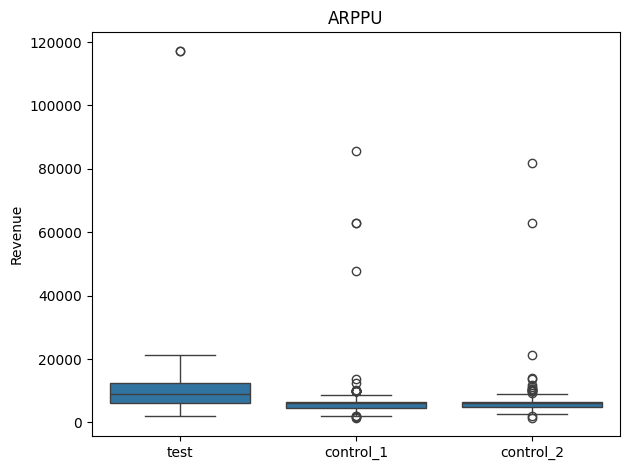

In [38]:
# Plot
arppu_long = pd.concat([
    pd.DataFrame({'sample': name, 'revenue': vals}) 
    for name, vals in arppu_data.items()
])

ax = sns.boxplot(data=arppu_long, x='sample', y='revenue')
ax.set_xlabel(None)
ax.set_ylabel('Revenue')
ax.set_title('ARPPU')

plt.tight_layout()
plt.show()

In [39]:
# Check normality
for name in ['test', 'control_1', 'control_2']:
    stat, p = stats.shapiro(arppu_data[name])
    print(f"{name}: p-value={p:.4f}")

test: p-value=0.0000
control_1: p-value=0.0000
control_2: p-value=0.0000


Distributions are heavily right-skewed due to outliers.

Box plots below exclude the top 5% of values for a clearer view of the central tendency.

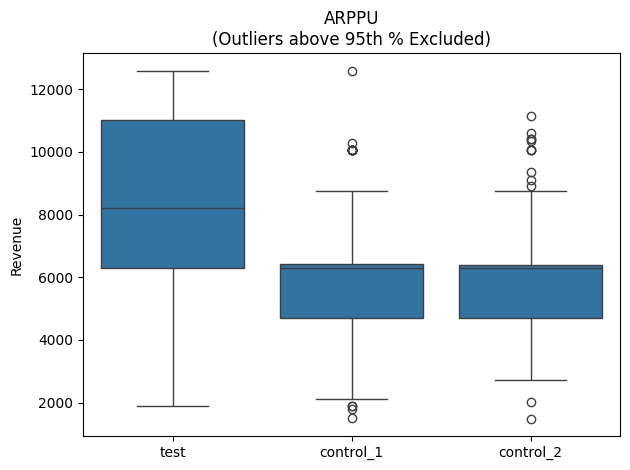

In [40]:
# Filter values at or below the 95th percentile (for visualization only)
arppu_no_outliers = {}
for name in ['test', 'control_1', 'control_2']:
    q95 = arppu_data[name].quantile(0.95)
    arppu_no_outliers[name] = arppu_data[name][arppu_data[name] <= q95]
    
# Plot
arppu_long = pd.concat([
    pd.DataFrame({'sample': name, 'revenue': vals}) 
    for name, vals in arppu_no_outliers.items()
])

ax = sns.boxplot(data=arppu_long, x='sample', y='revenue')
ax.set_xlabel(None)
ax.set_ylabel('Revenue')
ax.set_title('ARPPU\n(Outliers above 95th % Excluded)')

plt.tight_layout()
plt.show()

In [41]:
# Statistical test: Kruskal-Wallis H
stats.kruskal(arppu_data['test'], arppu_data['control_1'], arppu_data['control_2'])

KruskalResult(statistic=np.float64(23.633330340099462), pvalue=np.float64(7.380529528846392e-06))

In [42]:
# Pairwise comparisons with Bonferroni correction 
pairs = [('test', 'control_1'), ('test', 'control_2'), ('control_1', 'control_2')]
n_pairs = len(pairs)

for g1, g2 in pairs:
    stat, p = stats.mannwhitneyu(arppu_data[g1], arppu_data[g2], alternative='two-sided')
    p_cor = min(p * n_pairs, 1.0)
    print(f"{g1} vs {g2}: adj p-value={p_cor:.4f} {'***' if p_cor < 0.05 else ''}")

test vs control_1: adj p-value=0.0000 ***
test vs control_2: adj p-value=0.0000 ***
control_1 vs control_2: adj p-value=1.0000 


ARPPU is significantly higher in the test group than in controls. However, the test group has roughly 1.5 fewer paying users. We therefore cannot confidently attribute this to a positive treatment effect - it is likely a selection bias artefact: due to the low conversion rate, only the most motivated (and highest-spending) users completed the purchase in the test group (note also that the conversion rate is lower in the test group).

## Retention

In [43]:
# Compute retention
retention_matrices = {}

for name in ['test', 'control_1', 'control_2']:
    u_df = datasets[f'merged_{name}'].drop_duplicates(subset='uid').copy()
    u_df = u_df[~u_df['joined_at'].isna()]
    
    u_df['days_list'] = u_df['visit_days'].apply(
        lambda x: [int(d.strip()) for d in x.split(',')] if pd.notna(x) else []
    )
    
    u_df['cohort'] = u_df['joined_at'].dt.to_period('W')
    
    # Explode visit_days into long format
    rows = []
    for _, row in u_df.iterrows():
        for day in row['days_list']:
            rows.append({'uid': row['uid'], 'cohort': row['cohort'], 'day': day})
    
    long_df = pd.DataFrame(rows)
    
    cohort_pivot = long_df.groupby(['cohort', 'day'])['uid']\
        .nunique()\
        .reset_index()\
        .pivot_table(index='cohort', columns='day', values='uid')\
        .loc[:, 1:30]
    
    cohort_size = long_df.groupby('cohort', as_index=False)['uid'].nunique()
    cohort_size = cohort_size.rename(columns={'uid':'Cohort size'})
    
    cohort_size_indexed = cohort_size.set_index('cohort')['Cohort size']
    retention_matrix = cohort_pivot.divide(cohort_size_indexed, axis=0)
    retention_matrix['Cohort size'] = cohort_size_indexed
    
    retention_matrices[name] = retention_matrix

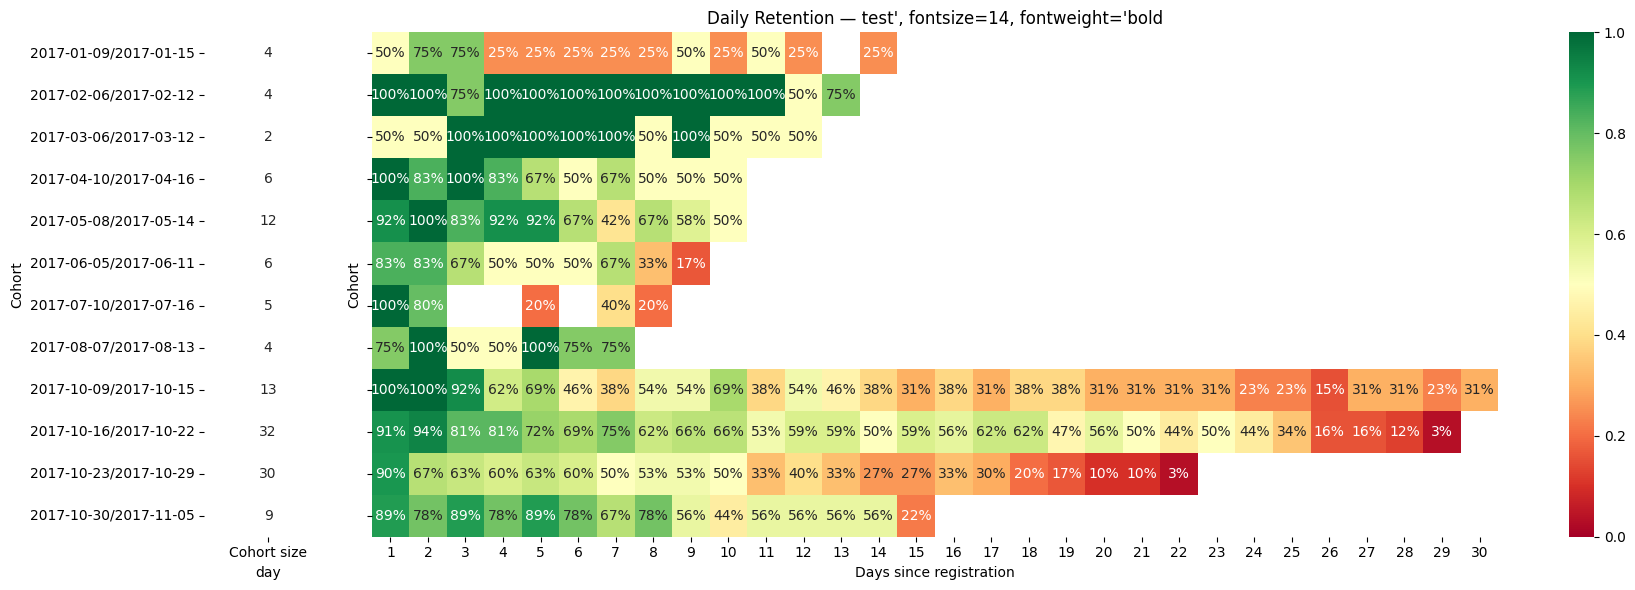

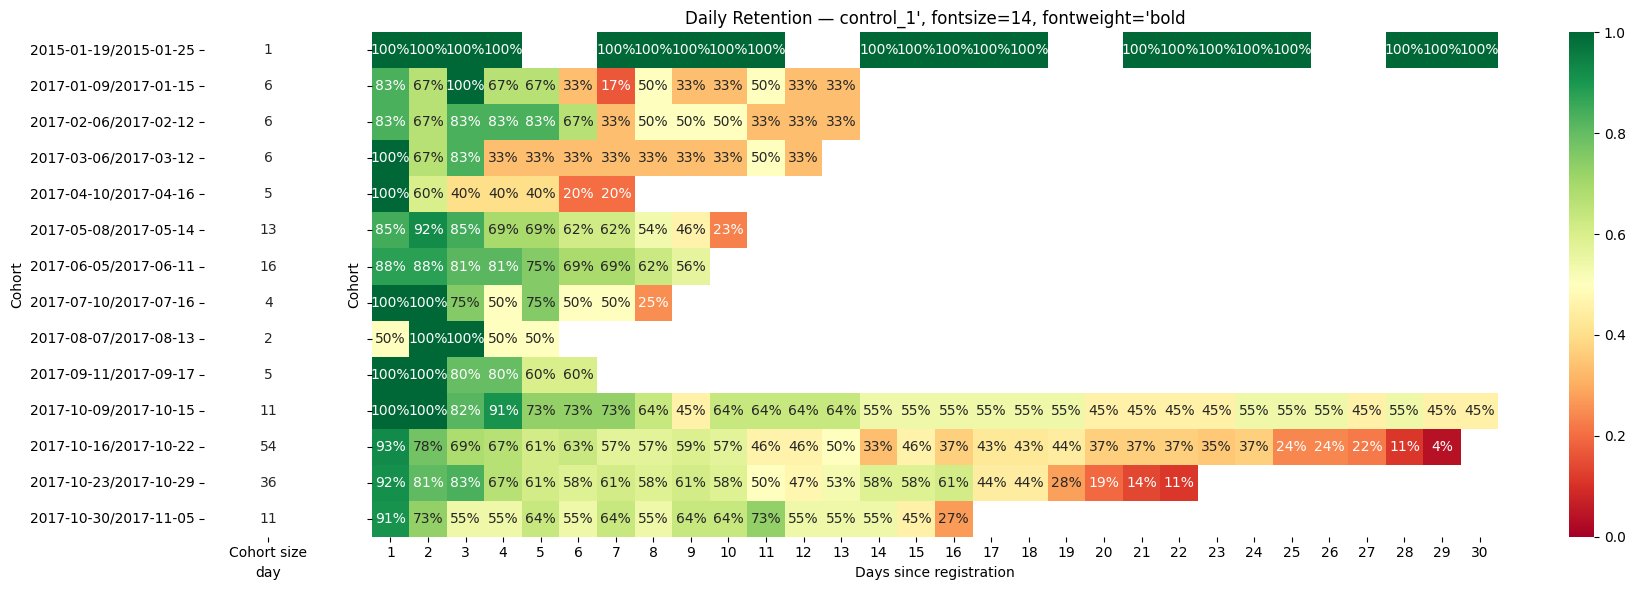

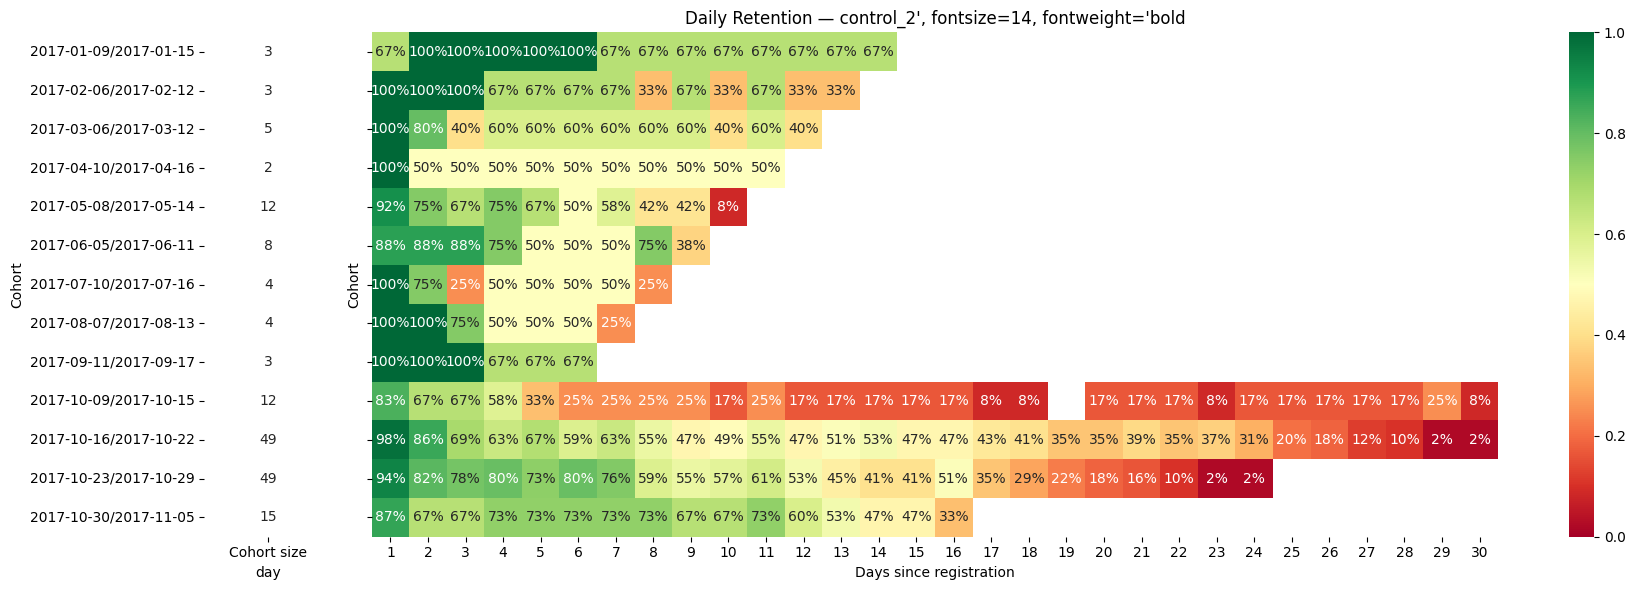

In [44]:
# Heatmap
for name in ['test', 'control_1', 'control_2']:
    retention_matrix = retention_matrices[name]
    
    # Separate cohort size from retention matrix
    cohort_size_df = retention_matrix[['Cohort size']]
    retention_only = retention_matrix.drop(columns=['Cohort size'])
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                             sharey=True,
                             gridspec_kw={'width_ratios': [1, 11]})
    
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=axes[0])
    axes[0].set(ylabel='Cohort')
    
    sns.heatmap(retention_only,
                mask=retention_only.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=axes[1],
                vmin=0, vmax=1)
    axes[1].set_title(f"Daily Retention — {name}', fontsize=14, fontweight='bold")
    axes[1].set(xlabel='Days since registration', ylabel='Cohort')
    
    fig.tight_layout()
    plt.show()

Let's compare retention at day 1 and day 10 using a statistical test

In [45]:
# Retention at day 1 and day 10
ret_1_10 = pd.DataFrame()
for name in ['test', 'control_1', 'control_2']:
    ret = retention_matrices[name][[1, 10]]
    ret.columns = [f'{name}_1',f'{name}_10']
    ret = ret.reset_index('cohort')
    
    if len(ret_1_10)==0:
        ret_1_10 = ret
    else:
        ret_1_10 = ret_1_10.merge(ret, on='cohort', how='left')

In [46]:
# Statistical test
days_to_check = [1, 10]

for day in days_to_check:
    stat, p = stats.kruskal(ret_1_10[f'test_{day}'], ret_1_10[f'control_1_{day}'], ret_1_10[f'control_2_{day}'], 
                            nan_policy='omit')
    print(f"Day {day}: p-value={p:.4f}")

Day 1: p-value=0.6174
Day 10: p-value=0.5431


No significant differences between groups at either day 1 or day 10

## Failed transactions

In [47]:
# Count of failed transactions
failed_prop = []
for name in ['test', 'control_1', 'control_2']:
    t_df = datasets[f'transactions_{name}']
    
    premium = t_df[t_df['product_type'] == 'premium_no_trial']
    total = len(premium)
    successful = (premium['successful_transaction'] == True).sum()
    failed = (premium['successful_transaction'] == False).sum()
    failed_prop.append(failed/total)
    
    print(f"{name}: {failed}/{total} = {failed/total:.1%}")

test: 6/75 = 8.0%
control_1: 2/104 = 1.9%
control_2: 3/106 = 2.8%


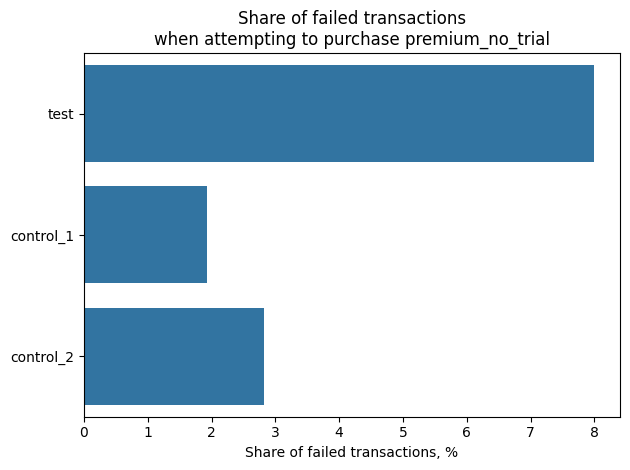

In [48]:
# Plot
ax = sns.barplot(y=['test', 'control_1', 'control_2'], x=[100*prop for prop in failed_prop])
ax.set_ylabel(None)
ax.set_xlabel('Share of failed transactions, %')
ax.set_title('Share of failed transactions\nwhen attempting to purchase premium_no_trial')

plt.tight_layout()
plt.show()

Even Fisher's exact test requires at least 5 observations per cell for reliable pairwise comparisons; chi-square requires even more. With fewer than 5 failed transactions in two of the three groups, no statistical test can yield a reliable result here. Visual inspection suggests a higher failure rate in the test group.

The share of failed transactions in the test group exceeds 5%, indicating a potential systematic bug in one or more of the new payment methods.

# Conclusion

The experiment should be considered **unsuccessful**. Conversion to a full subscription (`premium_no_trial`) in the test group is significantly lower than in both control groups (1.32% vs 2.07% and 2.18%). At the same time, the share of failed transactions is notably higher in the test group (8.0% vs 1.9% and 2.8% in controls) pointing to a technical bug in one or more of the new payment methods. Daily retention shows no difference across groups, meaning the new payment methods did not affect how frequently users return to the app.

ARPPU is significantly higher in the test group (medians: 8,216 vs 6,292 and 6,292), but this is not a positive treatment effect - it is a selection bias artefact: due to the high failure rate and presumably higher price, only the most motivated and highest-spending users completed a purchase.

The immediate priority should be fixing the payment processing bug in the new methods, after which a follow-up experiment with revised pricing would be warranted.